# 01 - Vectors, Spaces & Linear Transformations

**Book references:** *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong) [https://drive.google.com/file/d/1KsG9bntb0vD9QrUvHrlR2vqBQSr_V0J9/view]

- §2.1–2.3, pp.19–34 (Systems of Linear Equations, Matrices, Solving Systems of Linear Equations)
- §2.4–2.8, pp.35–63 (Vector Spaces, Linear Independence, Basis and Rank, Linear Mappings, Affine Spaces)

In [1]:
# For storing figures in local 'figures' folder
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [ ]:
# Visualize linear transformation using matrix
def visualize_linear_transformation(A: np.ndarray, title: str, savepath: Path = None):
    """Show a unit grid + basis vectors before and after applying matrix A.
    This is the picture to have in your head every time you see 'Ax'.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    lines = np.linspace(-1, 2, 7)
    grid_points = []
    for x in lines:
        seg = np.stack([np.full(50, x), np.linspace(-1, 2, 50)])
        grid_points.append(seg)
    for y in lines:
        seg = np.stack([np.linspace(-1, 2, 50), np.full(50, y)])
        grid_points.append(seg)

    e1, e2 = np.array([1, 0]), np.array([0, 1])

    for ax, transform, subtitle in [
        (axes[0], False, "Before: standard basis"),
        (axes[1], True, "After: A @ (grid)"),
    ]:
        for seg in grid_points:
            pts = A @ seg if transform else seg
            ax.plot(pts[0], pts[1], color="lightgray", linewidth=0.8, zorder=1)

        v1 = A @ e1 if transform else e1
        v2 = A @ e2 if transform else e2
        ax.quiver(0, 0, *v1, angles="xy", scale_units="xy", scale=1,
                   color="#2563eb", width=0.012, label="e1 -> A@e1" if transform else "e1")
        ax.quiver(0, 0, *v2, angles="xy", scale_units="xy", scale=1,
                   color="#dc2626", width=0.012, label="e2 -> A@e2" if transform else "e2")
        ax.set_xlim(-2, 3); ax.set_ylim(-2, 3)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_aspect("equal")
        ax.set_title(subtitle)
        ax.legend(loc="upper left", fontsize=9)

    fig.suptitle(title)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

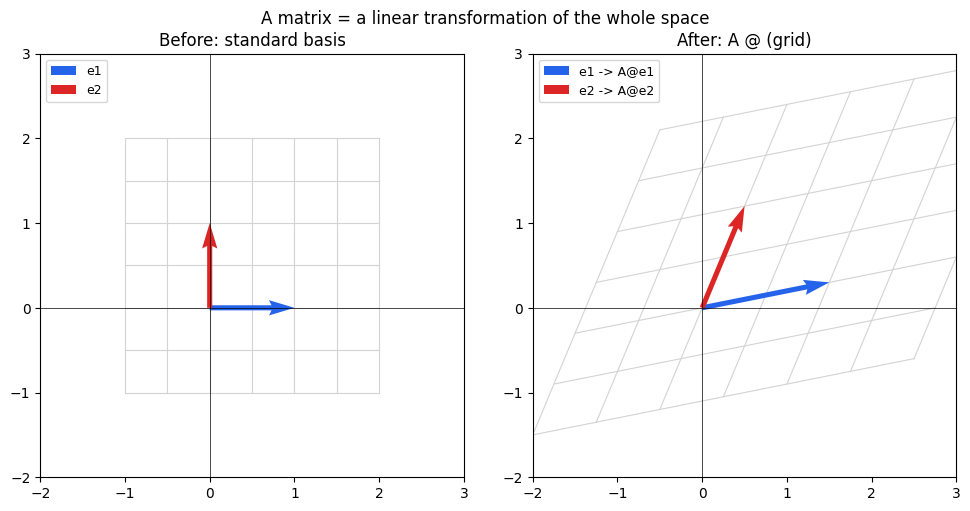

In [3]:
A_shear = np.array([[1.5, 0.5],
                     [0.3, 1.2]])
visualize_linear_transformation(
    A_shear, "A matrix = a linear transformation of the whole space",
    FIG_DIR / "linear_transformation.png")

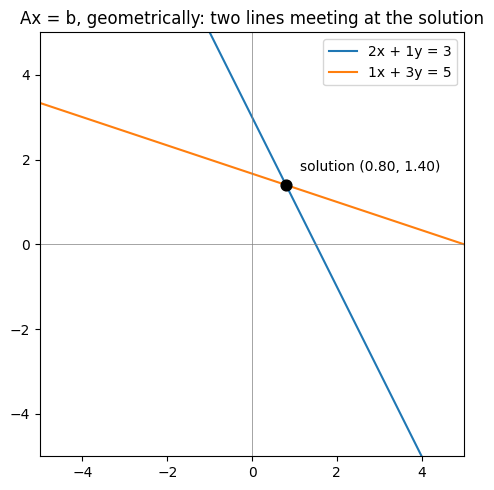

In [ ]:
# Visualize linear equations in 2-dimensional space
def visualize_linear_system_2d(A: np.ndarray, b: np.ndarray, savepath: Path = None):
    """A is (2,2), b is (2,). Plot both equations as lines and mark the
    solution (if unique) where they intersect."""
    fig, ax = plt.subplots(figsize=(5, 5))
    x_vals = np.linspace(-5, 5, 200)

    for i in range(2):
        a1, a2 = A[i]
        bi = b[i]
        if abs(a2) > 1e-9:
            y_vals = (bi - a1 * x_vals) / a2
            ax.plot(x_vals, y_vals, label=f"{a1:.0f}x + {a2:.0f}y = {bi:.0f}")
        else:
            ax.axvline(bi / a1, label=f"{a1:.0f}x = {bi:.0f}")

    if abs(np.linalg.det(A)) > 1e-9:
        solution = np.linalg.solve(A, b)
        ax.scatter(*solution, color="black", zorder=5, s=60)
        ax.annotate(f"solution ({solution[0]:.2f}, {solution[1]:.2f})",
                    solution, textcoords="offset points", xytext=(10, 10))

    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    ax.legend()
    ax.set_title("Ax = b, geometrically: two lines meeting at the solution")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

A_sys = np.array([[2., 1.],
                   [1., 3.]])
b_sys = np.array([3., 5.])
visualize_linear_system_2d(A_sys, b_sys, FIG_DIR / "linear_system_2d.png")

In [ ]:
# Check if two vectors are linearly independent or not
def is_linearly_independent(vectors: np.ndarray) -> bool:
    return bool(np.linalg.matrix_rank(vectors) == vectors.shape[0])

indep = np.array([[1., 0., 0.], [0., 1., 0.]])
dep = np.array([[1., 0., 0.], [2., 0., 0.]])
print("independent set:", is_linearly_independent(indep))
print("dependent set:  ", is_linearly_independent(dep))

independent set: True
dependent set:   False


In [ ]:
# Check rank of a matrix
def rank_demo():
    examples = {
        "full rank (independent rows)": np.array([[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]]),
        "rank-deficient (row3 = row1 + row2)": np.array([[1., 0., 0.], [0., 1., 0.], [1., 1., 0.]]),
        "duplicate rows": np.array([[2., 1.], [4., 2.]]),
    }
    for name, M in examples.items():
        r = np.linalg.matrix_rank(M)
        print(f"{name}: shape={M.shape}, rank={r}, independent={is_linearly_independent(M)}")

rank_demo()

full rank (independent rows): shape=(3, 3), rank=3, independent=True
rank-deficient (row3 = row1 + row2): shape=(3, 3), rank=2, independent=False
duplicate rows: shape=(2, 2), rank=1, independent=False


In [ ]:
# Solve linear system with gaussian elimination
def gaussian_elimination(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Solve Ax = b via Gaussian elimination with partial pivoting (from scratch)."""
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = A.shape[0]
    for col in range(n):
        pivot_row = np.argmax(np.abs(A[col:, col])) + col
        if pivot_row != col:
            A[[col, pivot_row]] = A[[pivot_row, col]]
            b[[col, pivot_row]] = b[[pivot_row, col]]
        for row in range(col + 1, n):
            factor = A[row, col] / A[col, col]
            A[row, col:] -= factor * A[col, col:]
            b[row] -= factor * b[col]
    x = np.zeros(n)
    for row in range(n - 1, -1, -1):
        x[row] = (b[row] - A[row, row + 1:] @ x[row + 1:]) / A[row, row]
    return x

print("Gaussian elimination:", gaussian_elimination(A_sys, b_sys))
print("np.linalg.solve:     ", np.linalg.solve(A_sys, b_sys))

Gaussian elimination: [0.8 1.4]
np.linalg.solve:      [0.8 1.4]
